In [129]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string
from dateutil import parser

Pulling Data from Database

In [130]:
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']
url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'
engine = create_engine(url, echo=False)

In [131]:
with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {pg_schema};'))

In [132]:
with engine.begin() as conn: # Done with echo=False
    data_airports = conn.execute(text(f'''
                               SELECT * FROM mart_faa_stats; 
                                '''))
    data_flights = conn.execute(text(f'''
                               SELECT * FROM mart_rout_stats; 
                                '''))
    data_weather = conn.execute(text(f'''
                               SELECT * FROM mart_selected_faa_stats_weather; 
                                '''))    

### Let's create a dataframe out of that
df_airports = pd.DataFrame(data_airports.all()) 
df_flights = pd.DataFrame(data_flights.all())
df_weather = pd.DataFrame(data_weather.all())

Working with Data 

In [133]:
#display(df_airports.head())
display(df_airports.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   faa                              6 non-null      object
 1   city                             6 non-null      object
 2   country                          6 non-null      object
 3   numer_of_unique_dep_connections  6 non-null      int64 
 4   numer_of_unique_arr_connections  6 non-null      int64 
 5   total_planed_dep                 6 non-null      int64 
 6   total_planed_arr                 6 non-null      int64 
 7   total_canceled_dep               6 non-null      int64 
 8   total_canceled_arr               6 non-null      int64 
 9   total_diverted_dep               6 non-null      int64 
 10  total_diverted_arr               6 non-null      int64 
 11  total_actual_dep                 6 non-null      int64 
 12  total_actual_arr                 6 non-n

None

In [134]:
#display(df_flights.head())
display(df_flights.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype          
---  ------                           --------------  -----          
 0   origin                           30 non-null     object         
 1   origin_city                      30 non-null     object         
 2   origin_country                   30 non-null     object         
 3   dest                             30 non-null     object         
 4   dest_city                        30 non-null     object         
 5   dest_country                     30 non-null     object         
 6   total_planed_flights_on_rout     30 non-null     int64          
 7   unique_airlines_on_rout          30 non-null     int64          
 8   unique_planes_on_rout            30 non-null     int64          
 9   avg_actual_elapsed_time_on_rout  30 non-null     timedelta64[ns]
 10  avg_arr_delay                    30 non-null     tim

None

In [135]:
display(df_weather.head())
display(df_weather.info())

,faa,flight_date,numer_of_unique_dep_connections,total_planed_dep,total_canceled_dep,total_diverted_dep,total_actual_dep,numer_of_unique_arr_connections,total_planed_arr,total_canceled_arr,...,dewpoint_c,humidity_perc,precipitation_mm,snow_mm,wind_direction,wind_speed_kmh,wind_peakgust_kmh,pressure_hpa,condition_code,weather_condition
0,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-2.6,41.0,0.0,None,110,9.4,None,1030.6,3,Cloudy
1,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-4.3,30.0,0.0,None,150,11.2,None,1030.0,1,Clear
2,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-4.8,28.0,0.0,None,150,13.0,None,1029.7,1,Clear
3,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-6.8,24.0,0.0,None,160,9.4,None,1029.9,2,Fair
4,ATL,2022-12-01,139,911,2,0,909,5,73,0,...,-6.7,26.0,0.0,None,160,5.4,None,1030.1,2,Fair


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   faa                              8928 non-null   object        
 1   flight_date                      8928 non-null   object        
 2   numer_of_unique_dep_connections  8928 non-null   int64         
 3   total_planed_dep                 8928 non-null   int64         
 4   total_canceled_dep               8928 non-null   int64         
 5   total_diverted_dep               8928 non-null   int64         
 6   total_actual_dep                 8928 non-null   int64         
 7   numer_of_unique_arr_connections  8928 non-null   int64         
 8   total_planed_arr                 8928 non-null   int64         
 9   total_canceled_arr               8928 non-null   int64         
 10  total_diverted_arr               8928 non-null   int64      

None

Weather classification by airport

In [136]:
airports = ['ORD', 'DTW', 'DEN', 'JFK', 'ATL', 'LAX']

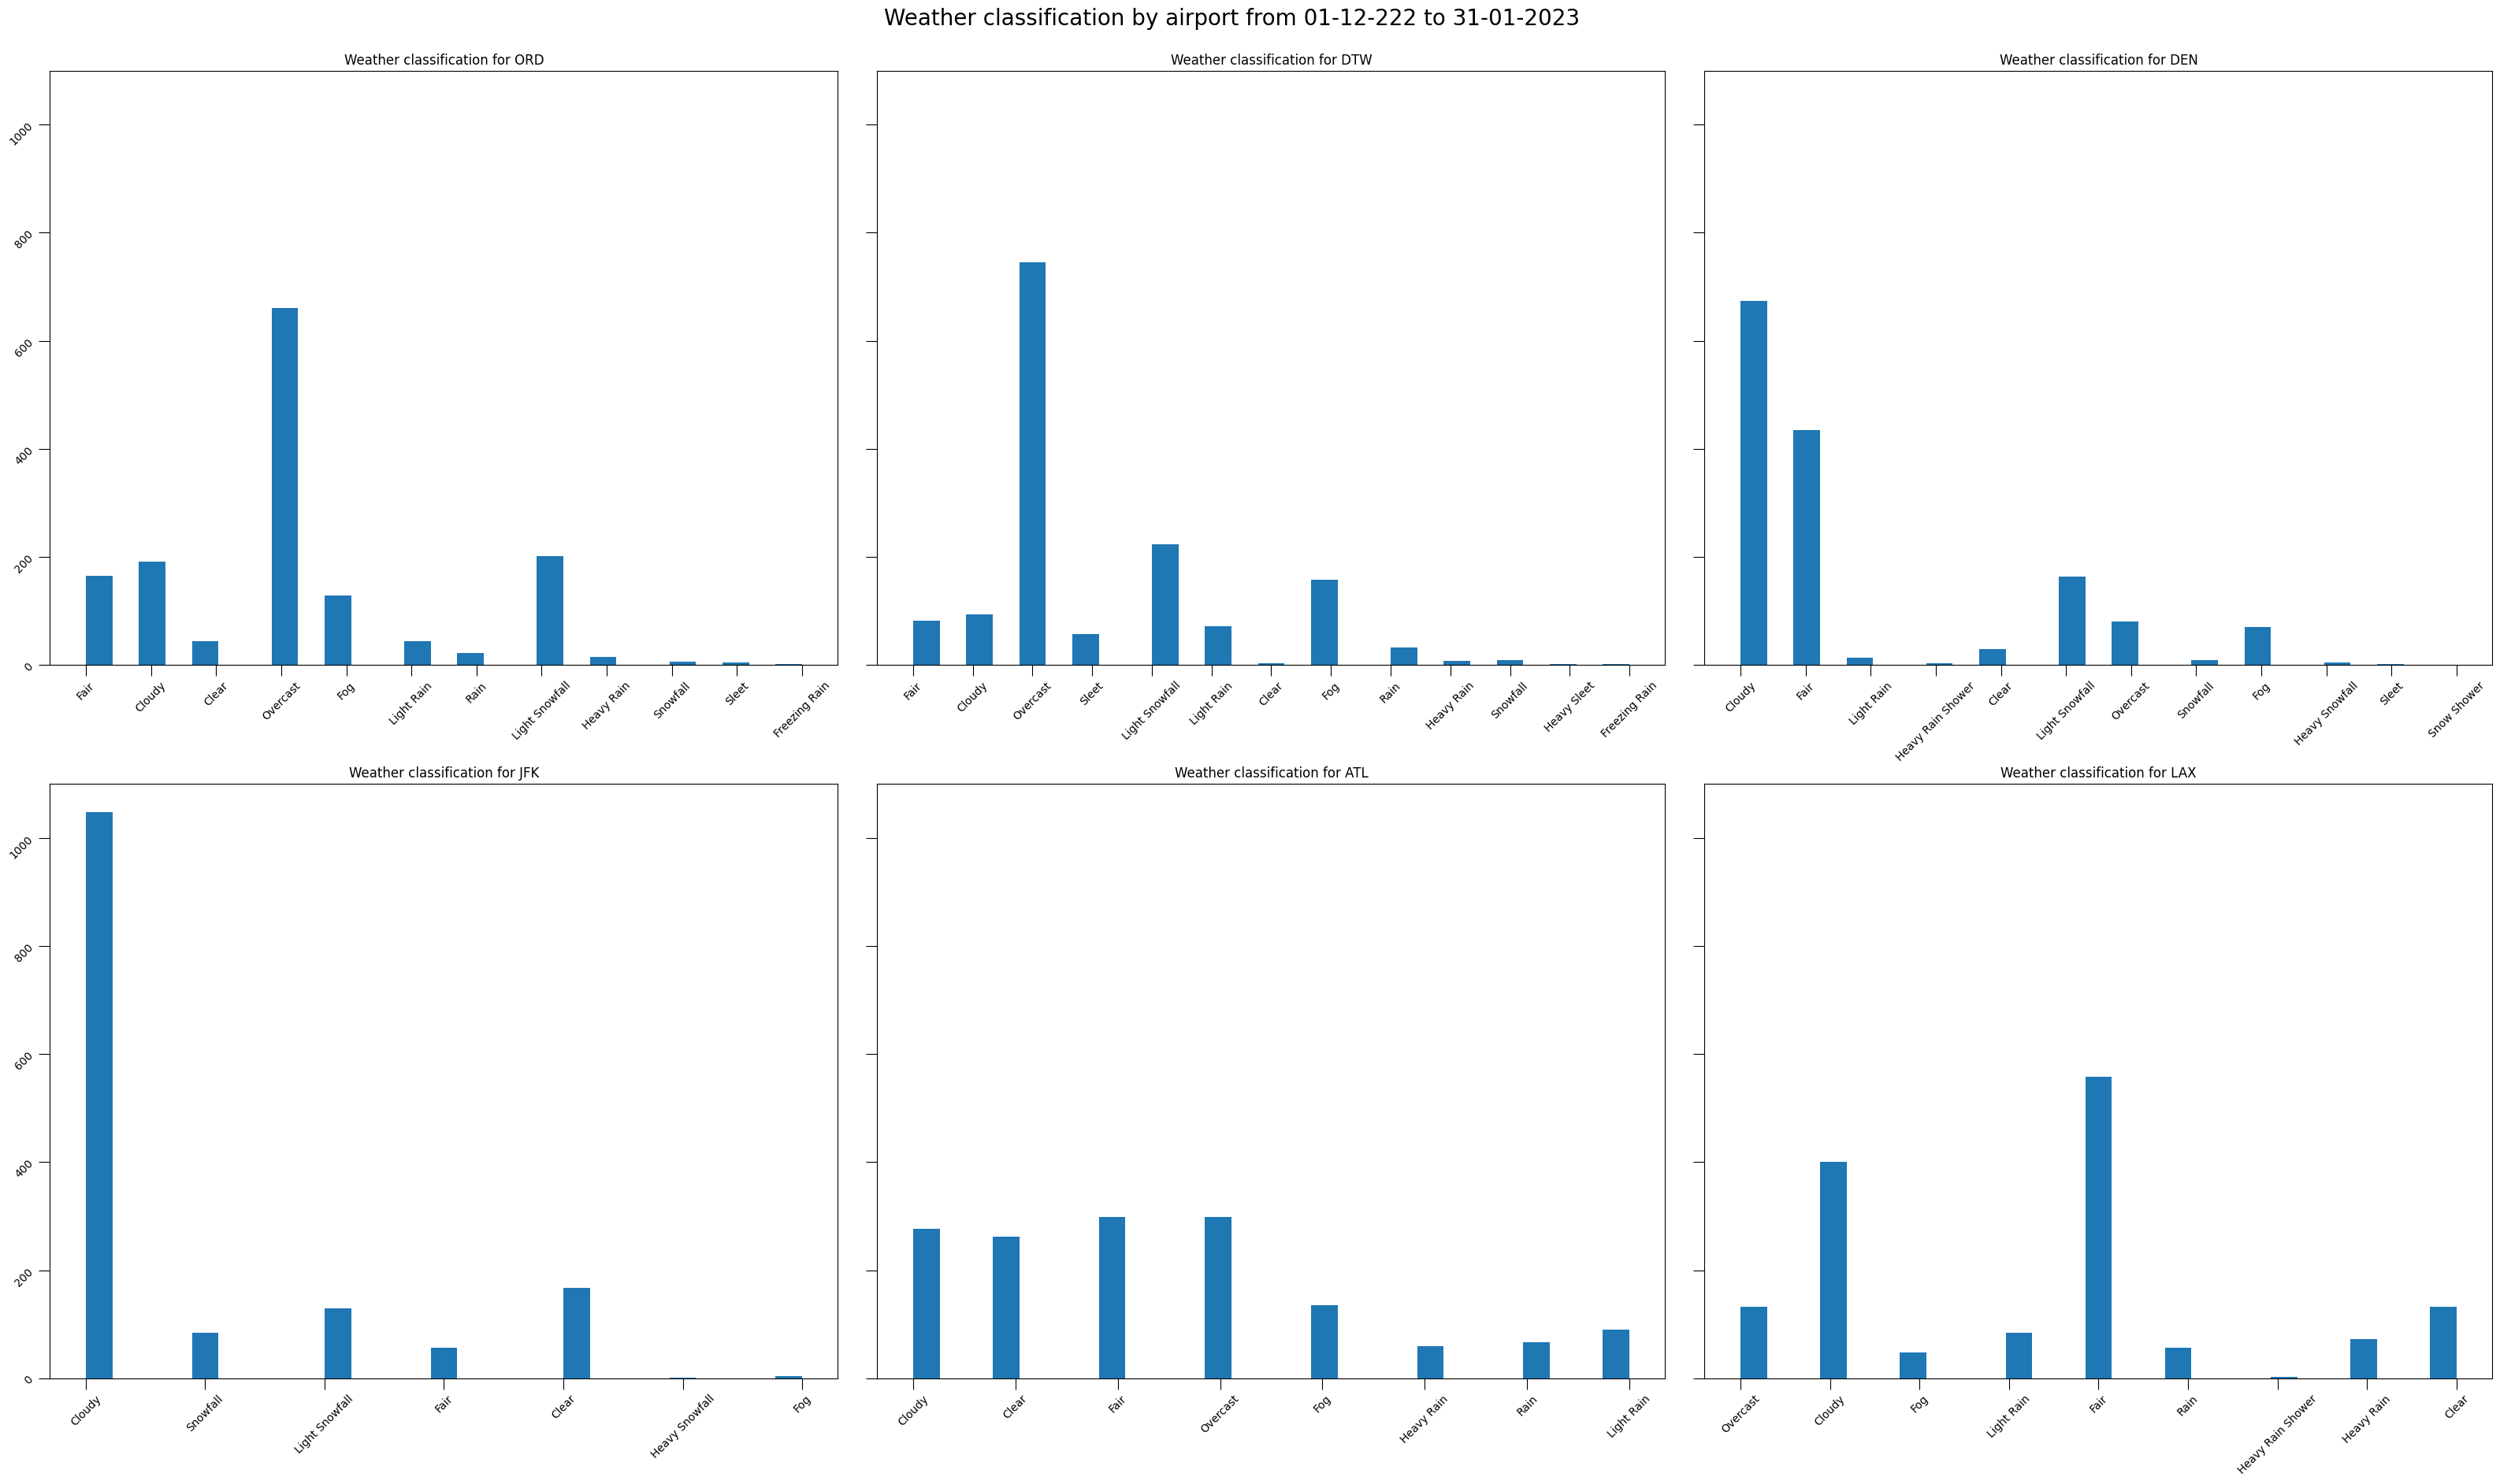

In [137]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
i = 0
plt.suptitle('Weather classification by airport from 01-12-222 to 31-01-2023', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[df_weather['faa'] == x]
        ax[a][b].hist(x=df_int['weather_condition'], bins = 27)
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Weather classification for {x}')
        display()
        i += 1

In [138]:
!pip install python-dateutil

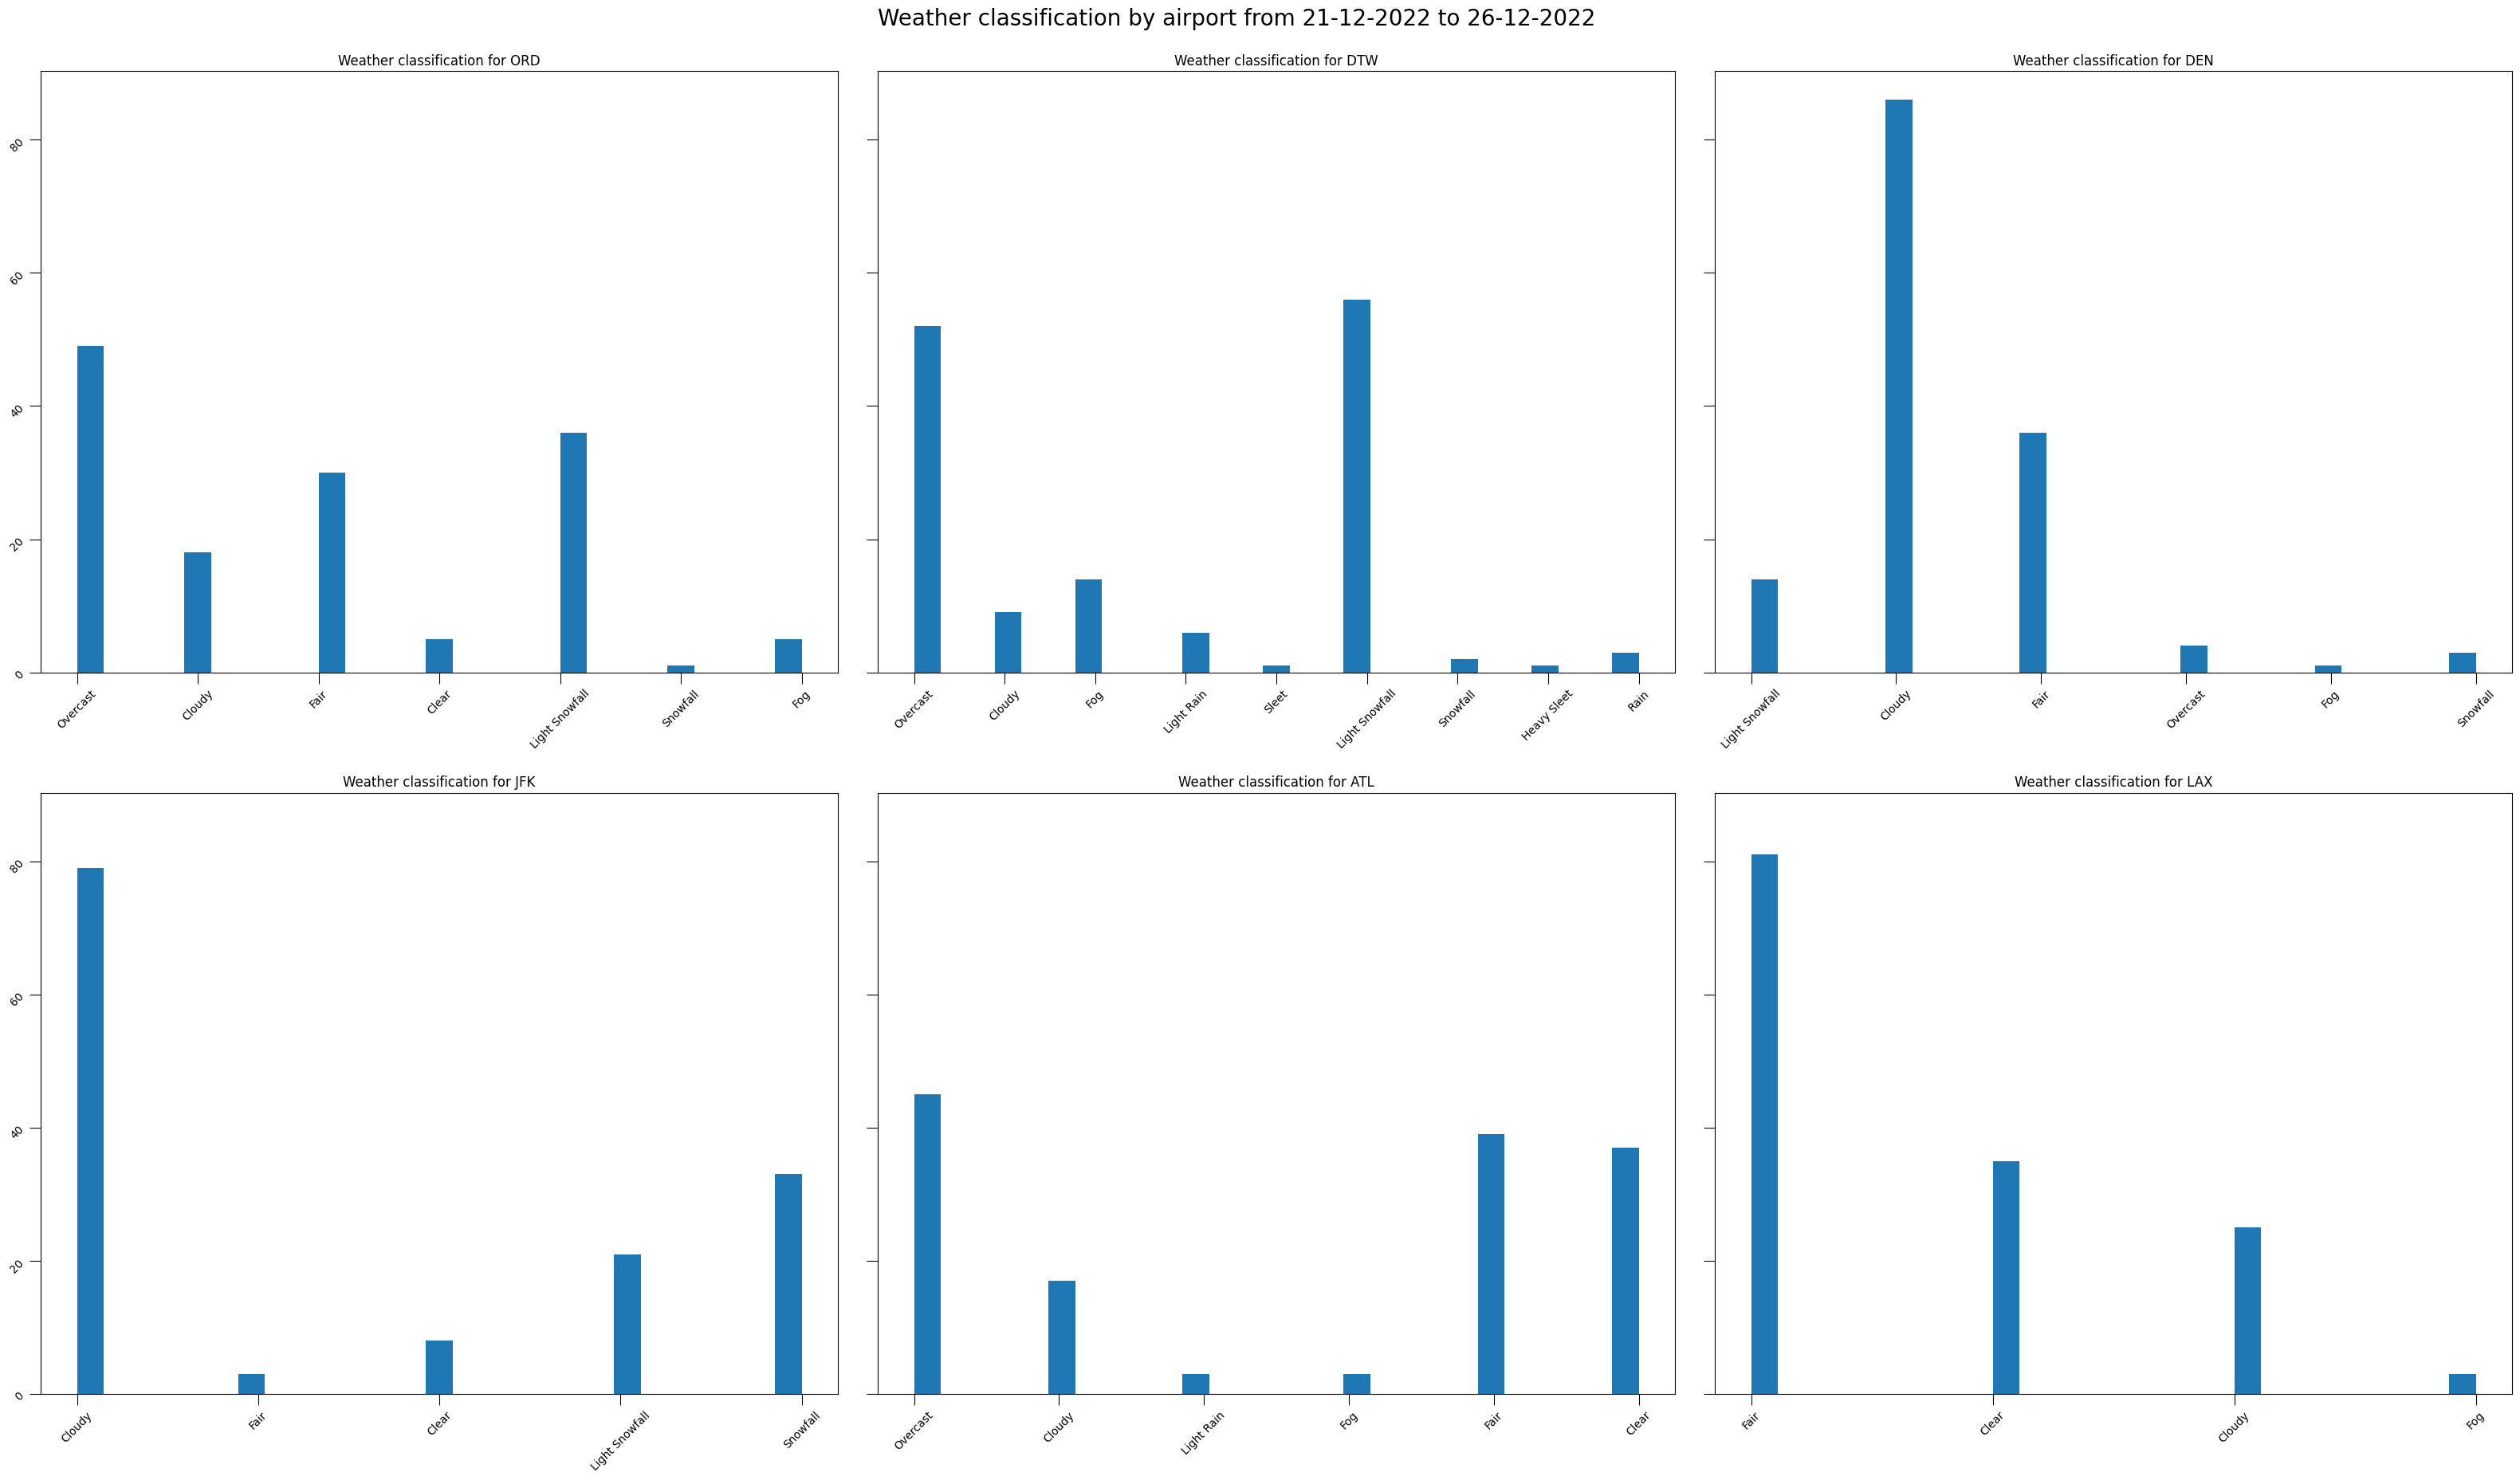

In [139]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-21'
end_date = '2022-12-26'
plt.suptitle('Weather classification by airport from 21-12-2022 to 26-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        ax[a][b].hist(x=df_int['weather_condition'], bins = 27)
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Weather classification for {x}')
        display()
        i += 1

Wind speeds by airport

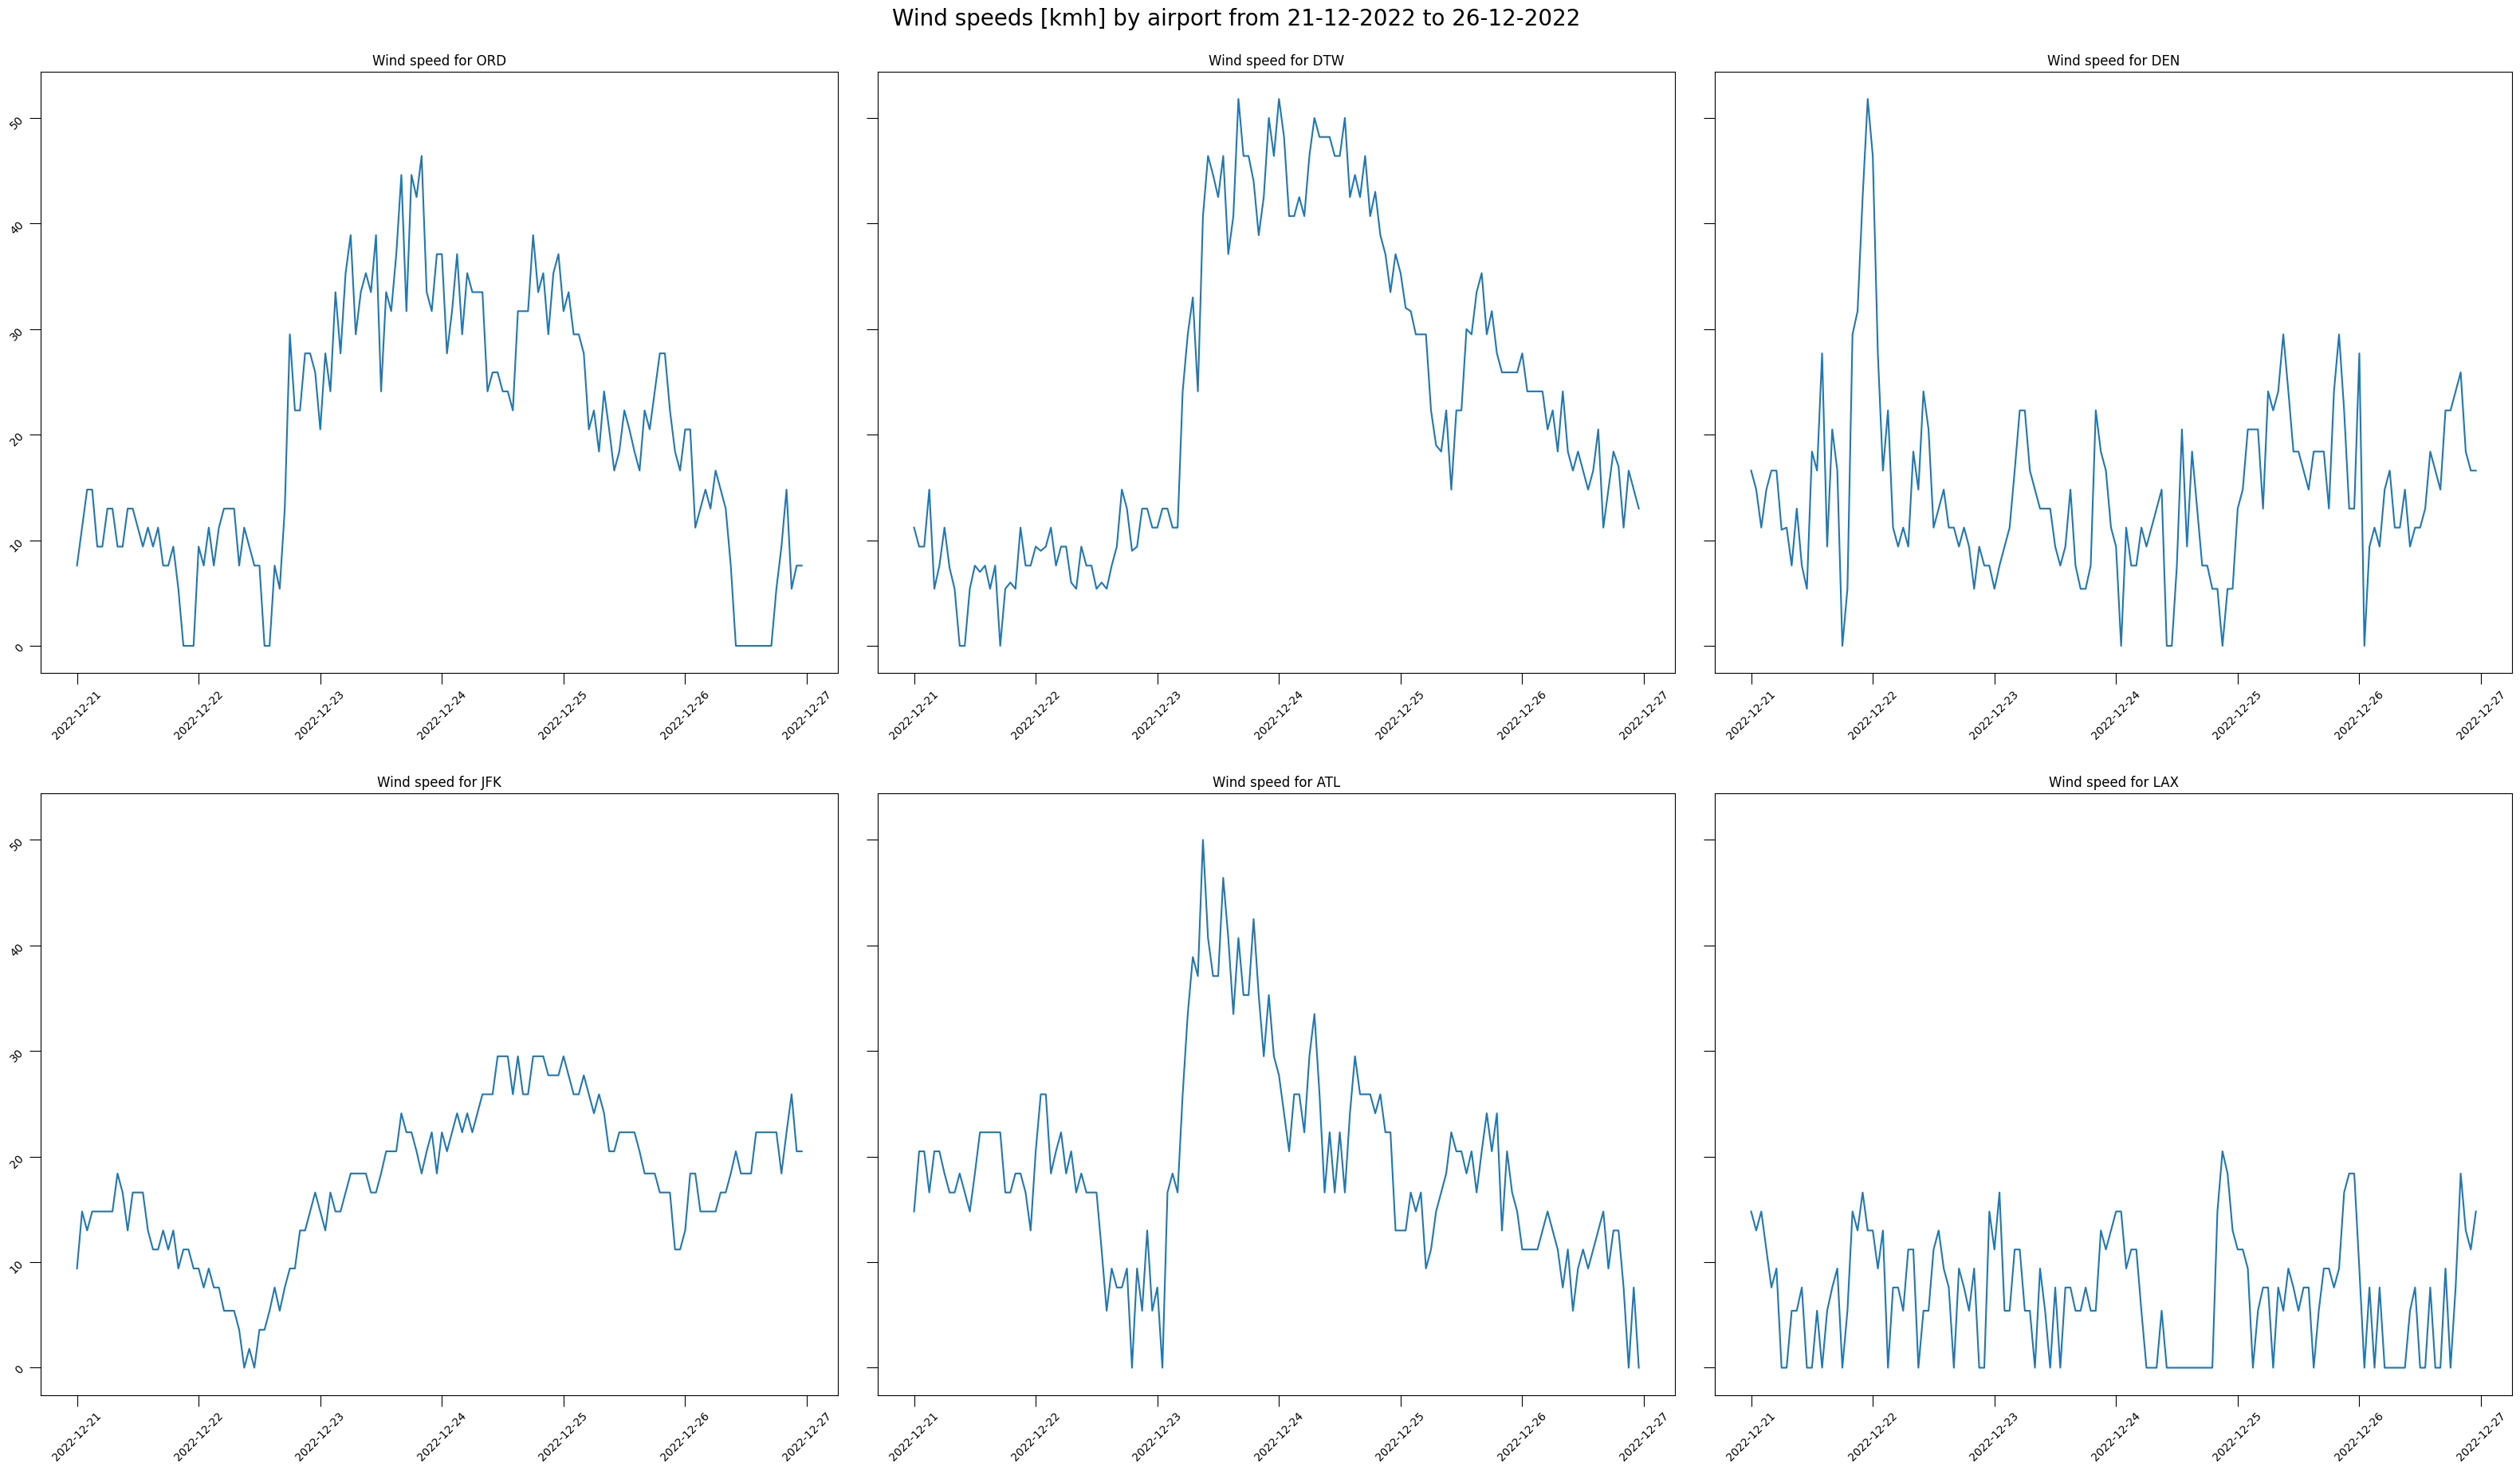

In [142]:
fig, ax = plt.subplots(2,3, figsize=(40,20), sharey=True)
plt.subplots_adjust(hspace = .2, wspace = .05, top = 0.94)
#plt.ylim(0,1000)
i = 0
start_date = '2022-12-21'
end_date = '2022-12-26'
plt.suptitle('Wind speeds [kmh] by airport from 21-12-2022 to 26-12-2022', fontsize=20)
for a in range (2):
    for b in range(3):
        x = airports[i]
        df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
        df_int = df_int.sort_values(by='timestamp')
        ax[a][b].plot(df_int['timestamp'],df_int['wind_speed_kmh'])
        ax[a][b].tick_params(labelrotation=45, size = 10)
        ax[a][b].set_title(f'Wind speed for {x}')
        display()
        i += 1

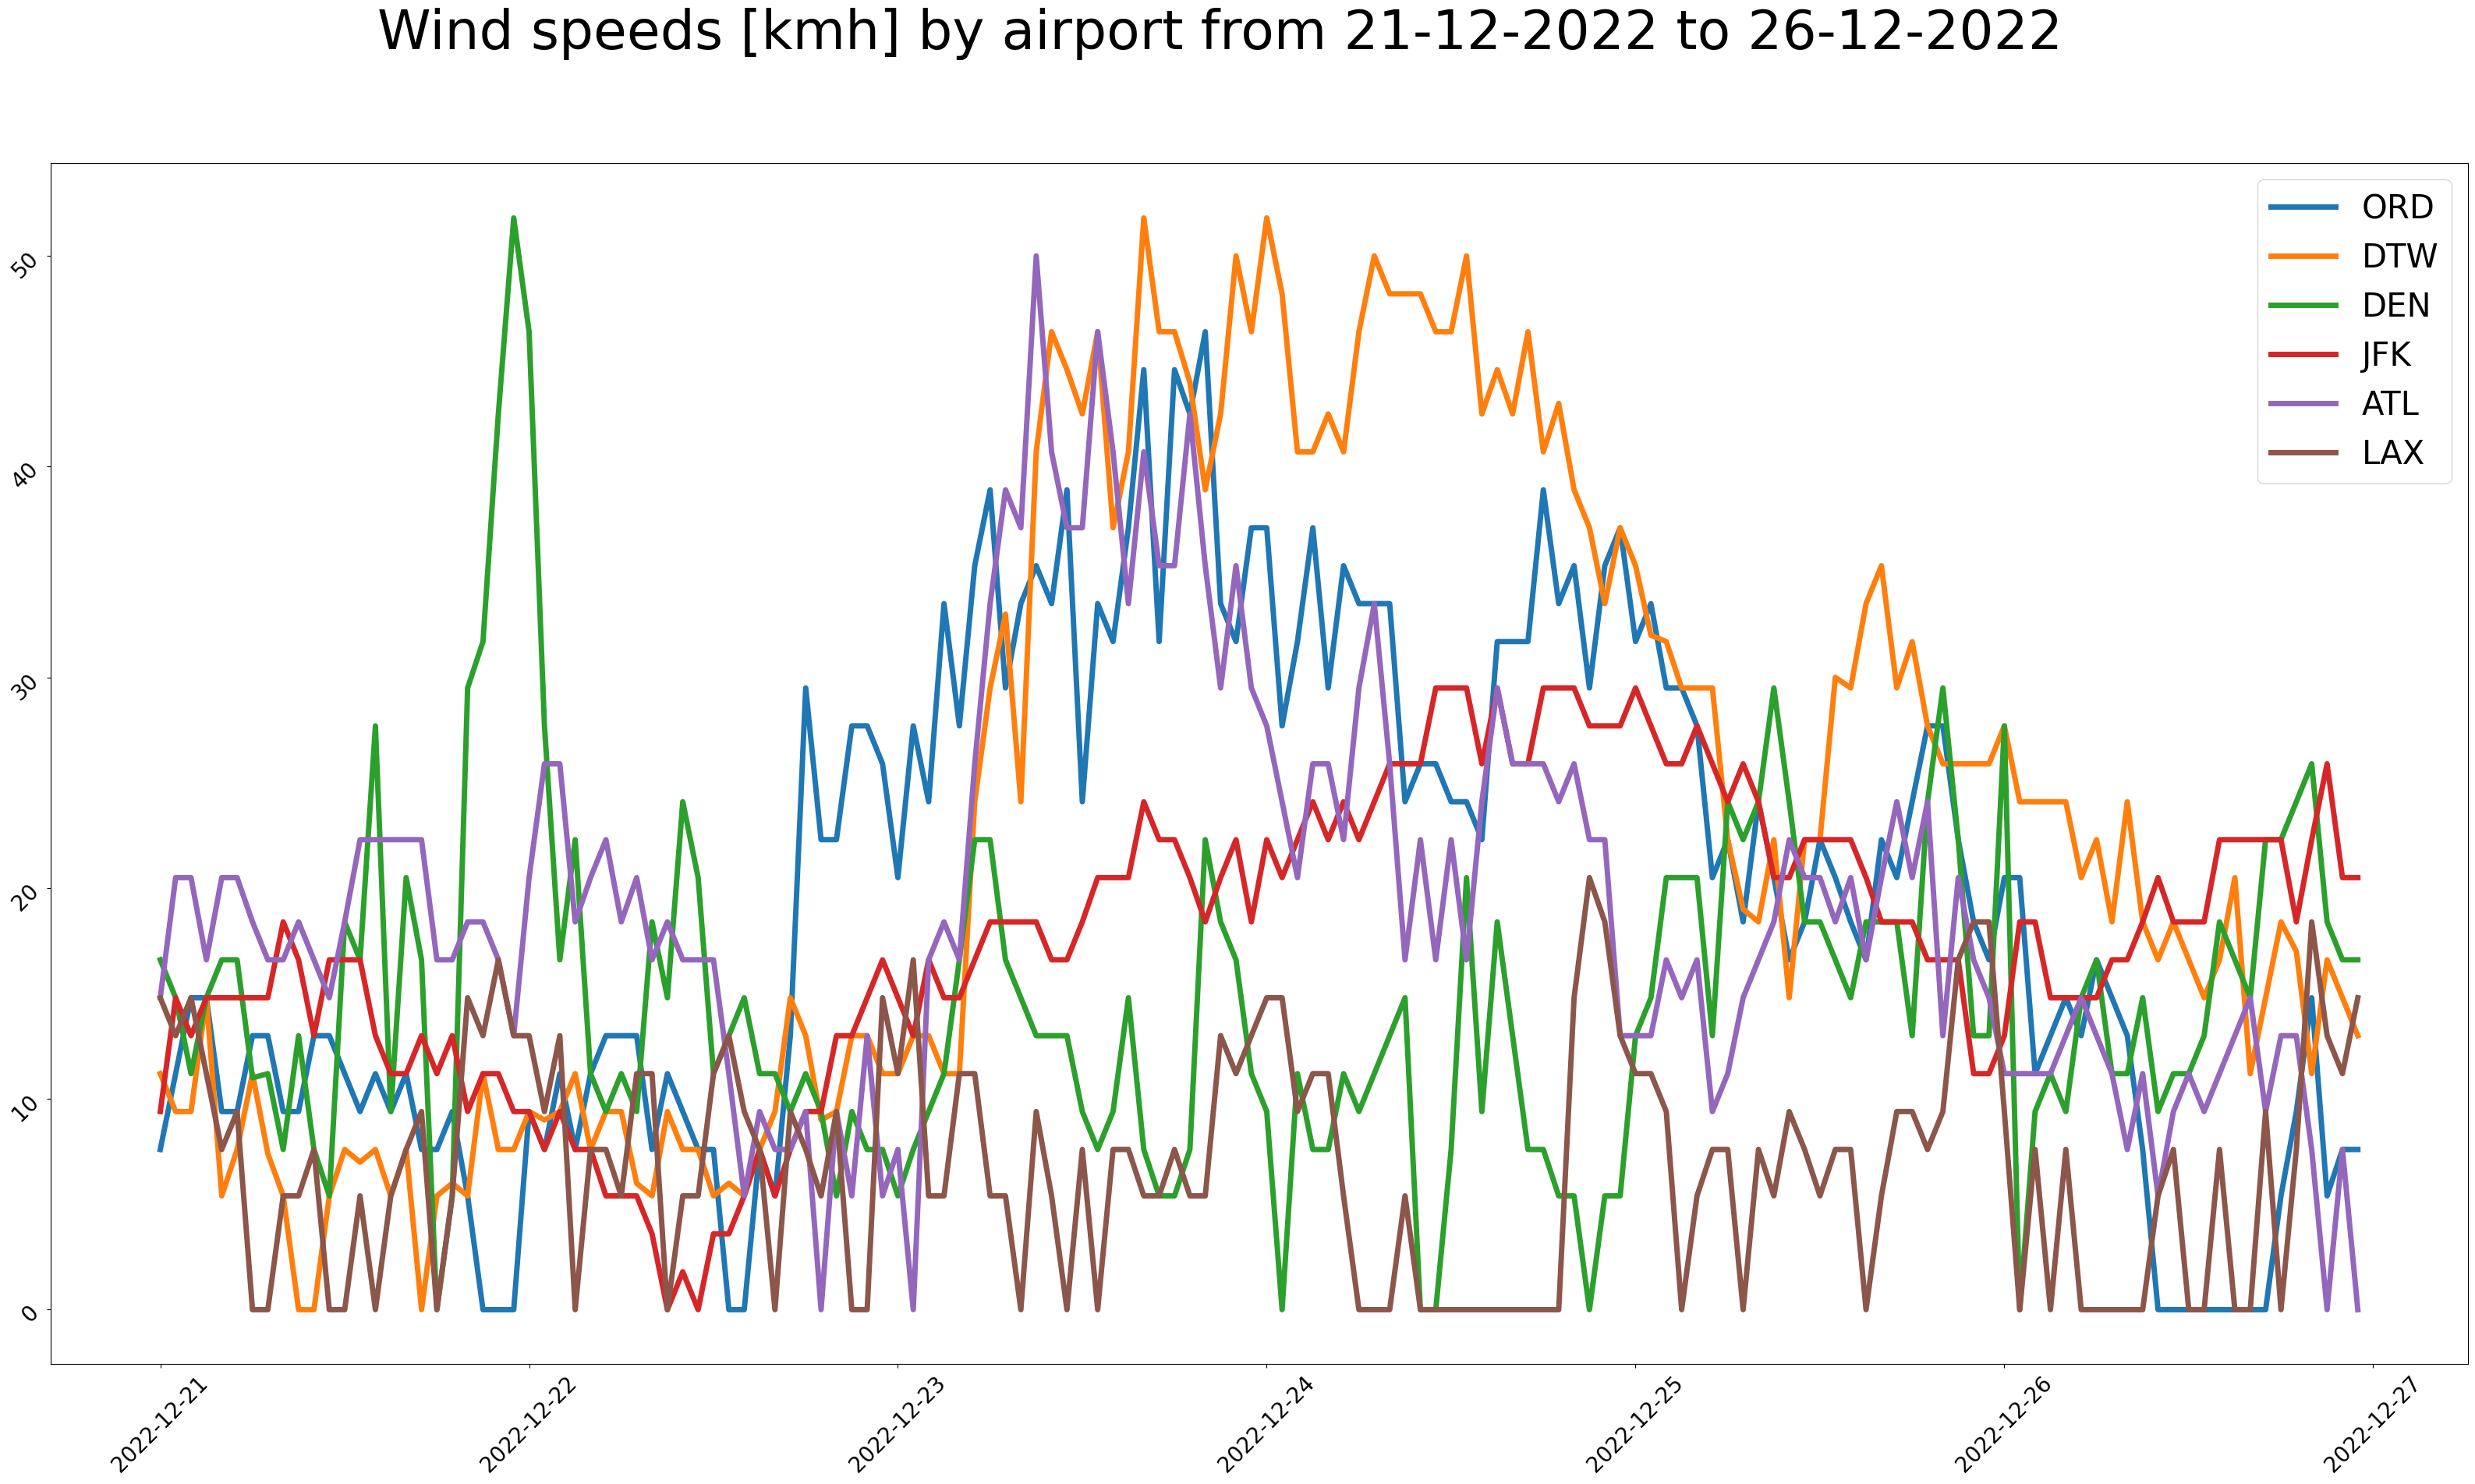

In [166]:
start_date = '2022-12-21'
end_date = '2022-12-26'
plt.figure(figsize= (40,20))
plt.suptitle('Wind speeds [kmh] by airport from 21-12-2022 to 26-12-2022', fontsize=50)
for x in airports:
    df_int = df_weather[(df_weather['faa'] == x) & (df_weather['date'] >= parser.parse(start_date).date()) & (df_weather['date'] <= parser.parse(end_date).date())]
    df_int = df_int.sort_values(by='timestamp')
    plt.plot(df_int['timestamp'],df_int['wind_speed_kmh'], linewidth = 5)
plt.tick_params(labelrotation=45, labelsize = 20)
plt.legend(airports, fontsize= 30)
display()
